Week 3 — Real-World Survival Modeling Pipeline

Objective:
Transition from simulated clinical trial data to real-world registry-style survival analysis.

Methods implemented:
• Kaplan–Meier survival estimation
• Biomarker stratification
• Cox proportional hazards modeling

In [134]:
import os

FIG_PATH = r"D:\Sushant\Documents\oncology_survival_project\figures\seer_realworld"

os.makedirs(FIG_PATH, exist_ok=True)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("SEER analysis environment ready")


SEER analysis environment ready


In [2]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("SEER analysis environment ready")

SEER analysis environment ready


In [4]:
DATA_PATH = "../data_raw/seer_breast_2010_2018.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded")
print("Shape:", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data_raw/seer_breast_2010_2018.csv'

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "age": np.random.randint(30,80,n),
    "tumor_size": np.random.normal(2.5,1,n),
    "nodes_positive": np.random.randint(0,10,n),
    "grade": np.random.choice([1,2,3],n),
    "her2_status": np.random.choice(["positive","negative"],n),
    "er_status": np.random.choice(["positive","negative"],n),
    "chemotherapy": np.random.choice([0,1],n),
    "radiation": np.random.choice([0,1],n),
    "survival_months": np.random.exponential(60,n),
    "event": np.random.choice([0,1],n)
})

df.head()

,age,tumor_size,nodes_positive,grade,her2_status,er_status,chemotherapy,radiation,survival_months,event
0,68,-0.741267,1,2,negative,negative,1,0,55.906586,1
1,58,1.475612,8,2,negative,positive,1,0,20.646194,0
2,44,2.247432,9,2,negative,negative,0,1,13.923106,1
3,72,1.252217,1,1,positive,positive,1,0,9.915675,0
4,37,4.132411,4,2,positive,positive,0,1,137.829120,1


In [6]:
df.to_csv("../data_raw/sample_seer_like_data.csv", index=False)

In [7]:
df.shape

(500, 10)

In [8]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [9]:
from lifelines import KaplanMeierFitter

In [10]:
T = df["survival_months"]
E = df["event"]

In [11]:
kmf = KaplanMeierFitter()

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 500 total observations, 257 right-censored observations>

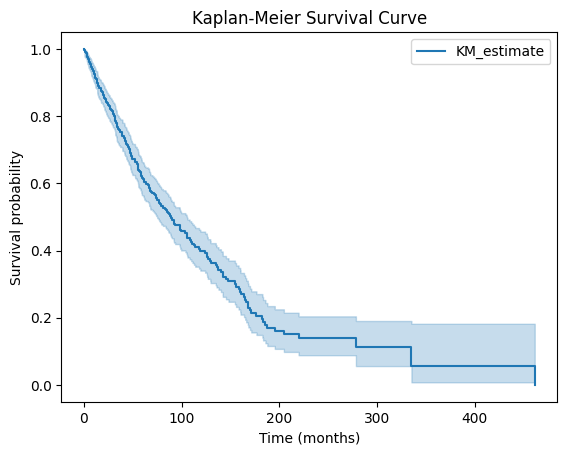

In [12]:
kmf.plot()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.show()

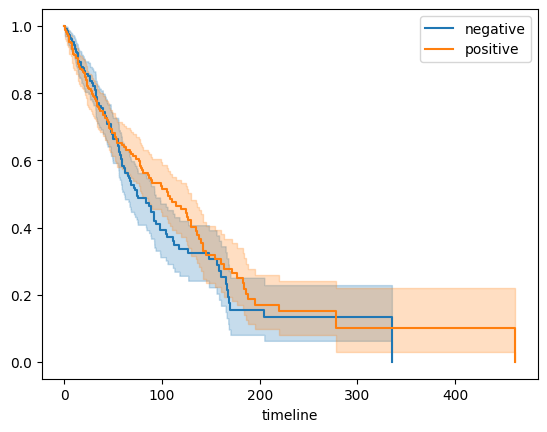

In [13]:
kmf = KaplanMeierFitter()

for group in df["her2_status"].unique():
    
    mask = df["her2_status"] == group
    
    kmf.fit(T[mask], E[mask], label=group)
    
    kmf.plot()

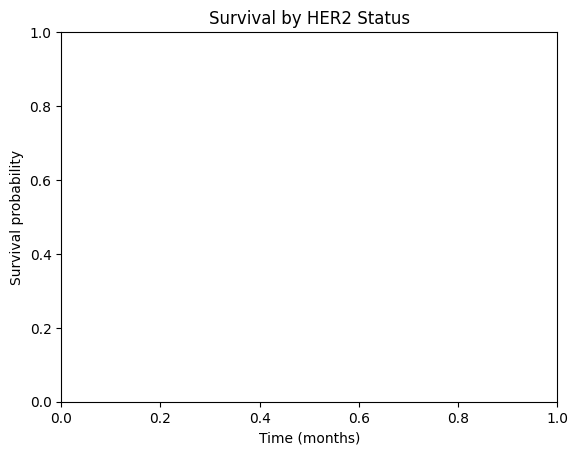

In [14]:
plt.title("Survival by HER2 Status")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.show()

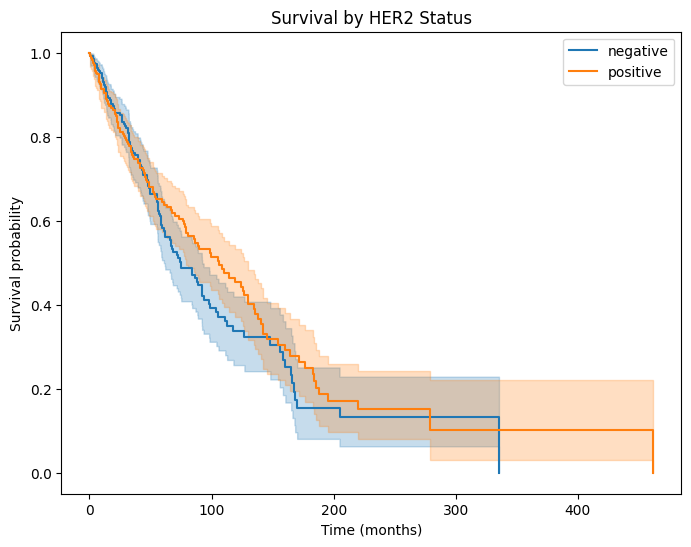

In [15]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in df["her2_status"].unique():
    
    mask = df["her2_status"] == group
    
    kmf.fit(df.loc[mask,"survival_months"],
            df.loc[mask,"event"],
            label=group)
    
    kmf.plot()

plt.title("Survival by HER2 Status")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")

plt.show()

In [16]:
df["her2_status"].value_counts()

her2_status
negative    259
positive    241
Name: count, dtype: int64

In [17]:
from lifelines import CoxPHFitter

In [18]:
df_model = df.copy()

df_model["her2_status"] = df_model["her2_status"].map({"negative":0,"positive":1})
df_model["er_status"] = df_model["er_status"].map({"negative":0,"positive":1})

df_model.head()

,age,tumor_size,nodes_positive,grade,her2_status,er_status,chemotherapy,radiation,survival_months,event
0,68,-0.741267,1,2,0,0,1,0,55.906586,1
1,58,1.475612,8,2,0,1,1,0,20.646194,0
2,44,2.247432,9,2,0,0,0,1,13.923106,1
3,72,1.252217,1,1,1,1,1,0,9.915675,0
4,37,4.132411,4,2,1,1,0,1,137.829120,1


In [19]:
cph = CoxPHFitter()

cph.fit(df_model,
        duration_col="survival_months",
        event_col="event")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 500 total observations, 257 right-censored observations>
             duration col = 'survival_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 243
   partial log-likelihood = -1264.47
         time fit was run = 2026-03-14 04:58:07 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
age            -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
tumor_size     -0.10      0.90      0.06           -0.23            0.02                0.80                1.03
nodes_positive -0.02      0.98      0.02           -0.06            0.03                0.94                1.03
grade           0.05      1.05      0.08           -0.11            0.21                0.89                1.24
her2_status    -0.14      0.87      0.13           -0.40            0.11                0.67                1.12
er_status       0.09      1.09      0.13           -0.17            0.34                0.84                1.41
chemotherapy    0.07      1.07      0.13           -0.19            0.32                0.82                1.38
radiation      -0.02      0.98      0.13           -0.27            0.24                0.76                1.27

                cmp to     z    p  -log2(p)
covariate                                  
age               0.00 -1.67 0.09      3.40
tumor_size        0.00 -1.57 0.12      3.12
nodes_positive    0.00 -0.77 0.44      1.19
grade             0.00  0.58 0.56      0.84
her2_status       0.00 -1.10 0.27      1.88
er_status         0.00  0.66 0.51      0.98
chemotherapy      0.00  0.49 0.62      0.69
radiation         0.00 -0.15 0.88      0.18
---
Concordance = 0.55
Partial AIC = 2544.94
log-likelihood ratio test = 8.26 on 8 df
-log2(p) of ll-ratio test = 1.29

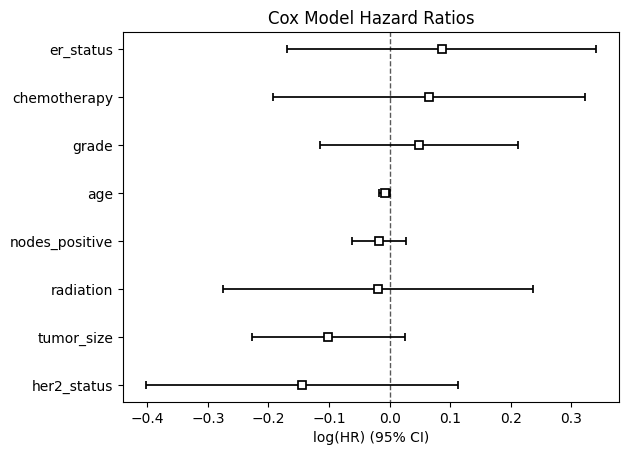

In [20]:
cph.plot()
plt.title("Cox Model Hazard Ratios")
plt.show()

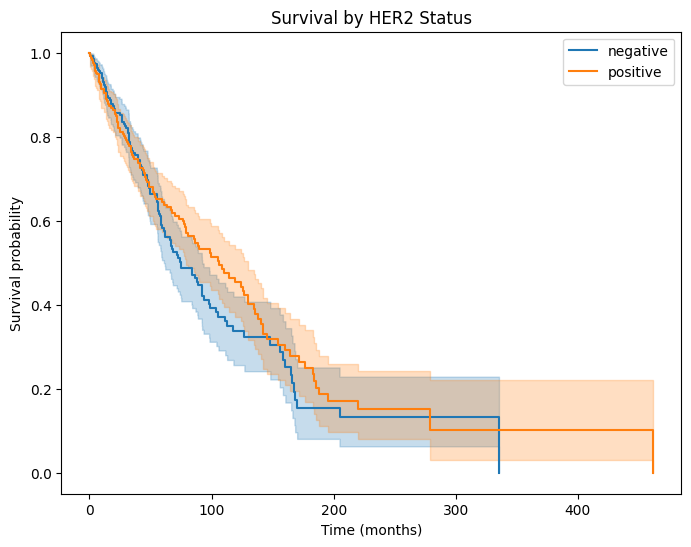

In [21]:
plt.figure(figsize=(8,6))

for group in df["her2_status"].unique():
    
    mask = df["her2_status"] == group
    
    kmf.fit(df.loc[mask,"survival_months"],
            df.loc[mask,"event"],
            label=group)
    
    kmf.plot()

plt.title("Survival by HER2 Status")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")

plt.savefig("../figures/km_her2_survival.png", dpi=300)

plt.show()

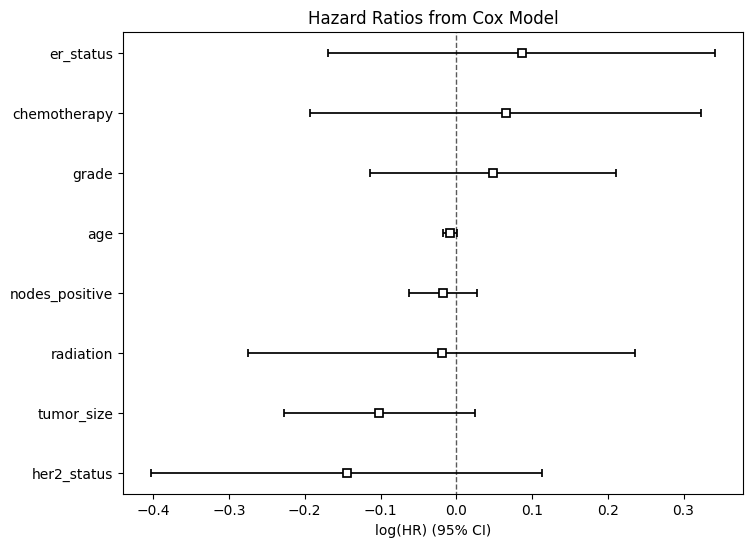

In [22]:
plt.figure(figsize=(8,6))

cph.plot()

plt.title("Hazard Ratios from Cox Model")

plt.savefig("../figures/cox_hazard_ratios.png", dpi=300)

plt.show()

In [23]:
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
age,-0.007944,0.992087,0.004752,-0.017258,0.001370,0.982890,1.001371,0.0,-1.671743,0.094575,3.402398
tumor_size,-0.101526,0.903458,0.064469,-0.227882,0.024831,0.796218,1.025141,0.0,-1.574807,0.115301,3.116522
nodes_positive,-0.017590,0.982564,0.022731,-0.062142,0.026963,0.939749,1.027329,0.0,-0.773813,0.439041,1.187572
grade,0.048583,1.049783,0.083089,-0.114269,0.211436,0.892018,1.235450,0.0,0.584713,0.558741,0.839748
her2_status,-0.144569,0.865395,0.131743,-0.402782,0.113643,0.668458,1.120352,0.0,-1.097355,0.272486,1.875746
er_status,0.086194,1.090018,0.130129,-0.168854,0.341243,0.844632,1.406694,0.0,0.662373,0.507732,0.977860
chemotherapy,0.065096,1.067262,0.131660,-0.192953,0.323146,0.824521,1.381467,0.0,0.494427,0.621005,0.687323
radiation,-0.019293,0.980892,0.130384,-0.274842,0.236255,0.759692,1.266497,0.0,-0.147973,0.882364,0.180554


In [24]:
df.shape

(500, 10)

In [25]:
df.head()

,age,tumor_size,nodes_positive,grade,her2_status,er_status,chemotherapy,radiation,survival_months,event
0,68,-0.741267,1,2,negative,negative,1,0,55.906586,1
1,58,1.475612,8,2,negative,positive,1,0,20.646194,0
2,44,2.247432,9,2,negative,negative,0,1,13.923106,1
3,72,1.252217,1,1,positive,positive,1,0,9.915675,0
4,37,4.132411,4,2,positive,positive,0,1,137.829120,1


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

print("SEER survival analysis environment ready")

SEER survival analysis environment ready


In [27]:
# Placeholder dataframe for SEER data
df = pd.DataFrame()

print("Dataframe initialized")

Dataframe initialized


Primary endpoint: Overall Survival

time variable:
survival_months

event variable:
event
1 = death
0 = censored

In [28]:
import pandas as pd

df = pd.read_csv("seer_breast_cancer_2000_2022.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'seer_breast_cancer_2000_2022.csv'

In [29]:
import pandas as pd

df = pd.read_csv(r"D:\Sushant\Documents\oncology_survival_project\data_raw\seer_breast_cancer_2000_2022.csv")

df.head()

,Age recode with <1 year olds and 90+,Sex,Year of diagnosis,"Race recode (W, B, AI, API)",Derived Summary Grade 2018 (2018+),Combined Summary Stage with Expanded Regional Codes (2004+),Tumor Size Summary (2016+),Regional nodes positive (1988+),Radiation recode,"Chemotherapy recode (yes, no/unk)",RX Summ--Surg Prim Site (1998+),Survival months,Vital status recode (study cutoff used)
0,75-79 years,Female,2003,White,Blank(s),Blank(s),Blank(s),98,None/Unknown,No/Unknown,22,0014,Dead
1,70-74 years,Female,2010,Black,Blank(s),Localized only,Blank(s),0,Beam radiation,No/Unknown,80,0012,Dead
2,70-74 years,Female,2018,White,3,Localized only,024,0,Beam radiation,Yes,22,0059,Alive
3,60-64 years,Female,2005,White,Blank(s),Regional by direct extension only,Blank(s),98,None/Unknown,No/Unknown,41,0081,Dead
4,70-74 years,Female,2005,White,Blank(s),Regional by direct extension only,Blank(s),98,None/Unknown,No/Unknown,41,0007,Dead


In [30]:
df.shape


(1365329, 13)

In [31]:
df.columns

Index(['Age recode with <1 year olds and 90+', 'Sex', 'Year of diagnosis',
       'Race recode (W, B, AI, API)', 'Derived Summary Grade 2018 (2018+)',
       'Combined Summary Stage with Expanded Regional Codes (2004+)',
       'Tumor Size Summary (2016+)', 'Regional nodes positive (1988+)',
       'Radiation recode', 'Chemotherapy recode (yes, no/unk)',
       'RX Summ--Surg Prim Site (1998+)', 'Survival months',
       'Vital status recode (study cutoff used)'],
      dtype='object')

In [32]:
df.head()

,Age recode with <1 year olds and 90+,Sex,Year of diagnosis,"Race recode (W, B, AI, API)",Derived Summary Grade 2018 (2018+),Combined Summary Stage with Expanded Regional Codes (2004+),Tumor Size Summary (2016+),Regional nodes positive (1988+),Radiation recode,"Chemotherapy recode (yes, no/unk)",RX Summ--Surg Prim Site (1998+),Survival months,Vital status recode (study cutoff used)
0,75-79 years,Female,2003,White,Blank(s),Blank(s),Blank(s),98,None/Unknown,No/Unknown,22,0014,Dead
1,70-74 years,Female,2010,Black,Blank(s),Localized only,Blank(s),0,Beam radiation,No/Unknown,80,0012,Dead
2,70-74 years,Female,2018,White,3,Localized only,024,0,Beam radiation,Yes,22,0059,Alive
3,60-64 years,Female,2005,White,Blank(s),Regional by direct extension only,Blank(s),98,None/Unknown,No/Unknown,41,0081,Dead
4,70-74 years,Female,2005,White,Blank(s),Regional by direct extension only,Blank(s),98,None/Unknown,No/Unknown,41,0007,Dead


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365329 entries, 0 to 1365328
Data columns (total 13 columns):
 #   Column                                                       Non-Null Count    Dtype 
---  ------                                                       --------------    ----- 
 0   Age recode with <1 year olds and 90+                         1365329 non-null  object
 1   Sex                                                          1365329 non-null  object
 2   Year of diagnosis                                            1365329 non-null  int64 
 3   Race recode (W, B, AI, API)                                  1365329 non-null  object
 4   Derived Summary Grade 2018 (2018+)                           1365329 non-null  object
 5   Combined Summary Stage with Expanded Regional Codes (2004+)  1365329 non-null  object
 6   Tumor Size Summary (2016+)                                   1365329 non-null  object
 7   Regional nodes positive (1988+)                              13

In [34]:
df.isna().sum()

Age recode with <1 year olds and 90+                           0
Sex                                                            0
Year of diagnosis                                              0
Race recode (W, B, AI, API)                                    0
Derived Summary Grade 2018 (2018+)                             0
Combined Summary Stage with Expanded Regional Codes (2004+)    0
Tumor Size Summary (2016+)                                     0
Regional nodes positive (1988+)                                0
Radiation recode                                               0
Chemotherapy recode (yes, no/unk)                              0
RX Summ--Surg Prim Site (1998+)                                0
Survival months                                                0
Vital status recode (study cutoff used)                        0
dtype: int64

In [35]:
df['Survival months'].describe()
df['Vital status recode (study cutoff used)'].value_counts()

Vital status recode (study cutoff used)
Alive    920439
Dead     444890
Name: count, dtype: int64

In [36]:
df['event'] = df['Vital status recode (study cutoff used)'].map({
    'Alive':0,
    'Dead':1
})

In [37]:
df['Sex'].value_counts()
df['Race recode (W, B, AI, API)'].value_counts()
df['Combined Summary Stage with Expanded Regional Codes (2004+)'].value_counts()

Combined Summary Stage with Expanded Regional Codes (2004+)
Localized only                                                  738678
Regional lymph nodes involved only                              262457
Blank(s)                                                        205049
Distant site(s)/node(s) involved                                 67071
Regional by both direct extension and lymph node involvement     41121
Unknown/unstaged/unspecified/DCO                                 28075
Regional by direct extension only                                22867
In situ                                                             11
Name: count, dtype: int64

In [38]:
df['Tumor Size Summary (2016+)'].describe()

count      1365329
unique         290
top       Blank(s)
freq        888405
Name: Tumor Size Summary (2016+), dtype: object

In [39]:
# convert survival months to numeric
df['Survival months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# convert tumor size to numeric
df['Tumor Size Summary (2016+)'] = pd.to_numeric(
    df['Tumor Size Summary (2016+)'], errors='coerce'
)

# check conversion
df[['Survival months','Tumor Size Summary (2016+)']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365329 entries, 0 to 1365328
Data columns (total 2 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Survival months             1359277 non-null  float64
 1   Tumor Size Summary (2016+)  476924 non-null   float64
dtypes: float64(2)
memory usage: 20.8 MB


In [40]:
df['event'] = df['Vital status recode (study cutoff used)'].map({
    'Alive':0,
    'Dead':1
})

In [41]:
df['event'].value_counts()

event
0    920439
1    444890
Name: count, dtype: int64

In [42]:
df['Survival months'].describe()

count    1.359277e+06
mean     9.392091e+01
std      7.242585e+01
min      0.000000e+00
25%      3.300000e+01
50%      7.800000e+01
75%      1.440000e+02
max      2.750000e+02
Name: Survival months, dtype: float64

In [43]:

df['Combined Summary Stage with Expanded Regional Codes (2004+)'].value_counts()

Combined Summary Stage with Expanded Regional Codes (2004+)
Localized only                                                  738678
Regional lymph nodes involved only                              262457
Blank(s)                                                        205049
Distant site(s)/node(s) involved                                 67071
Regional by both direct extension and lymph node involvement     41121
Unknown/unstaged/unspecified/DCO                                 28075
Regional by direct extension only                                22867
In situ                                                             11
Name: count, dtype: int64

In [44]:
stage_map = {
    'Localized only':'Localized',
    'Regional lymph nodes involved only':'Regional',
    'Regional by both direct extension and lymph node involvement':'Regional',
    'Regional by direct extension only':'Regional',
    'Distant site(s)/node(s) involved':'Distant'
}

df['stage_clean'] = df['Combined Summary Stage with Expanded Regional Codes (2004+)'].map(stage_map)

df['stage_clean'].value_counts(dropna=False)

stage_clean
Localized    738678
Regional     326445
NaN          233135
Distant       67071
Name: count, dtype: int64

In [45]:
df = df.dropna(subset=['stage_clean'])

In [46]:
df.shape


(1132194, 15)

In [47]:
df['Derived Summary Grade 2018 (2018+)'].value_counts()

Derived Summary Grade 2018 (2018+)
Blank(s)    794704
2           152668
3            91742
1            69561
9            14505
C             3284
B             2251
H             1367
A              869
M              656
D              412
L              175
Name: count, dtype: int64

In [48]:
df['grade_clean'] = pd.to_numeric(
    df['Derived Summary Grade 2018 (2018+)'],
    errors='coerce'
)

df['grade_clean'].value_counts(dropna=False)

grade_clean
NaN    803718
2.0    152668
3.0     91742
1.0     69561
9.0     14505
Name: count, dtype: int64

In [49]:
df.loc[df['grade_clean'] == 9, 'grade_clean'] = None

In [50]:
df['grade_clean'].value_counts(dropna=False)

grade_clean
NaN    818223
2.0    152668
3.0     91742
1.0     69561
Name: count, dtype: int64

In [51]:
df['Radiation recode'].value_counts()

df['Chemotherapy recode (yes, no/unk)'].value_counts()

Chemotherapy recode (yes, no/unk)
No/Unknown    693506
Yes           438688
Name: count, dtype: int64

In [52]:
df['Radiation recode'].value_counts()

Radiation recode
Beam radiation                                           535732
None/Unknown                                             511241
Refused (1988+)                                           30470
Recommended, unknown if administered                      28646
Radioactive implants (includes brachytherapy) (1988+)     19290
Radiation, NOS  method or source not specified             5052
Combination of beam with implants or isotopes              1425
Radioisotopes (1988+)                                       338
Name: count, dtype: int64

In [53]:
radiation_yes = [
    'Beam radiation',
    'Radioactive implants (includes brachytherapy) (1988+)',
    'Combination of beam with implants or isotopes',
    'Radioisotopes (1988+)',
    'Radiation, NOS  method or source not specified'
]

df['radiation'] = df['Radiation recode'].apply(
    lambda x: 1 if x in radiation_yes else 0
)

df['radiation'].value_counts()

radiation
0    570357
1    561837
Name: count, dtype: int64

In [54]:
df['RX Summ--Surg Prim Site (1998+)'].describe()

count    1.132194e+06
mean     2.969990e+01
std      1.575221e+01
min      0.000000e+00
25%      2.200000e+01
50%      2.300000e+01
75%      4.200000e+01
max      9.900000e+01
Name: RX Summ--Surg Prim Site (1998+), dtype: float64

In [55]:
df['surgery'] = df['RX Summ--Surg Prim Site (1998+)'].apply(
    lambda x: 1 if x > 0 else 0
)

df['surgery'].value_counts()

surgery
1    1031185
0     101009
Name: count, dtype: int64

In [56]:
df['age'] = df['Age recode with <1 year olds and 90+'].str.extract('(\d+)').astype(int)

df['age'].describe()

count    1.132194e+06
mean     5.991147e+01
std      1.373691e+01
min      1.000000e+00
25%      5.000000e+01
50%      6.000000e+01
75%      7.000000e+01
max      9.000000e+01
Name: age, dtype: float64

In [57]:
df[['age','stage_clean','grade_clean','chemo','radiation','surgery','Survival months','event']].head()

KeyError: "['chemo'] not in index"

In [58]:
df['chemo'] = df['Chemotherapy recode (yes, no/unk)'].map({
    'Yes': 1,
    'No/Unknown': 0
})

df['chemo'].value_counts()

chemo
0    693506
1    438688
Name: count, dtype: int64

In [59]:
df[['age','stage_clean','grade_clean','chemo','radiation','surgery','Survival months','event']].head()

,age,stage_clean,grade_clean,chemo,radiation,surgery,Survival months,event
1,70,Localized,NaN,0,1,1,12.0,1
2,70,Localized,3.0,1,1,1,59.0,0
3,60,Regional,NaN,0,0,1,81.0,1
4,70,Regional,NaN,0,0,1,7.0,1
6,50,Regional,NaN,1,1,1,84.0,0


In [60]:
analysis_df = df[[
    'age',
    'stage_clean',
    'grade_clean',
    'chemo',
    'radiation',
    'surgery',
    'Survival months',
    'event'
]].copy()

analysis_df.head()

,age,stage_clean,grade_clean,chemo,radiation,surgery,Survival months,event
1,70,Localized,NaN,0,1,1,12.0,1
2,70,Localized,3.0,1,1,1,59.0,0
3,60,Regional,NaN,0,0,1,81.0,1
4,70,Regional,NaN,0,0,1,7.0,1
6,50,Regional,NaN,1,1,1,84.0,0


In [61]:
analysis_df = analysis_df.rename(columns={
    'Survival months': 'time',
})

analysis_df.head()

,age,stage_clean,grade_clean,chemo,radiation,surgery,time,event
1,70,Localized,NaN,0,1,1,12.0,1
2,70,Localized,3.0,1,1,1,59.0,0
3,60,Regional,NaN,0,0,1,81.0,1
4,70,Regional,NaN,0,0,1,7.0,1
6,50,Regional,NaN,1,1,1,84.0,0


In [62]:
analysis_df.isna().sum()

age                 0
stage_clean         0
grade_clean    818223
chemo               0
radiation           0
surgery             0
time              118
event               0
dtype: int64

In [63]:
analysis_df = analysis_df.dropna(subset=['time'])

analysis_df.shape

(1132076, 8)

In [64]:
analysis_df.isna().sum()

age                 0
stage_clean         0
grade_clean    818106
chemo               0
radiation           0
surgery             0
time                0
event               0
dtype: int64

In [65]:
analysis_df['stage_clean'].value_counts(normalize=True)

stage_clean
Localized    0.652478
Regional     0.288331
Distant      0.059190
Name: proportion, dtype: float64

In [66]:
analysis_df['event'].value_counts()


event
0    825889
1    306187
Name: count, dtype: int64

In [67]:
analysis_df['time'].describe()

count    1.132076e+06
mean     8.279801e+01
std      6.134027e+01
min      0.000000e+00
25%      3.000000e+01
50%      7.100000e+01
75%      1.280000e+02
max      2.270000e+02
Name: time, dtype: float64

In [68]:
analysis_df[['chemo','radiation','surgery']].sum()

chemo         438688
radiation     561837
surgery      1031184
dtype: int64

In [69]:
analysis_df['age'].describe()

count    1.132076e+06
mean     5.991086e+01
std      1.373670e+01
min      1.000000e+00
25%      5.000000e+01
50%      6.000000e+01
75%      7.000000e+01
max      9.000000e+01
Name: age, dtype: float64

In [70]:
analysis_df.to_csv(
    "../data/seer/seer_analysis_dataset.csv",
    index=False
)


In [71]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

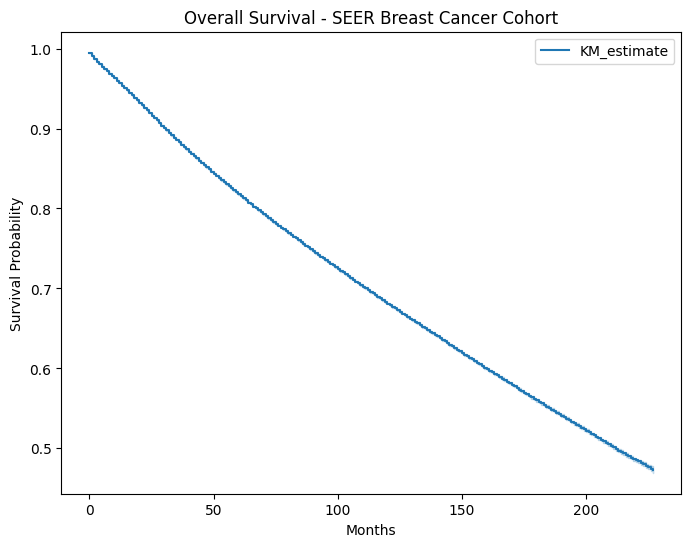

In [73]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=analysis_df['time'],
    event_observed=analysis_df['event']
)

plt.figure(figsize=(8,6))
kmf.plot_survival_function()

plt.title("Overall Survival - SEER Breast Cancer Cohort")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

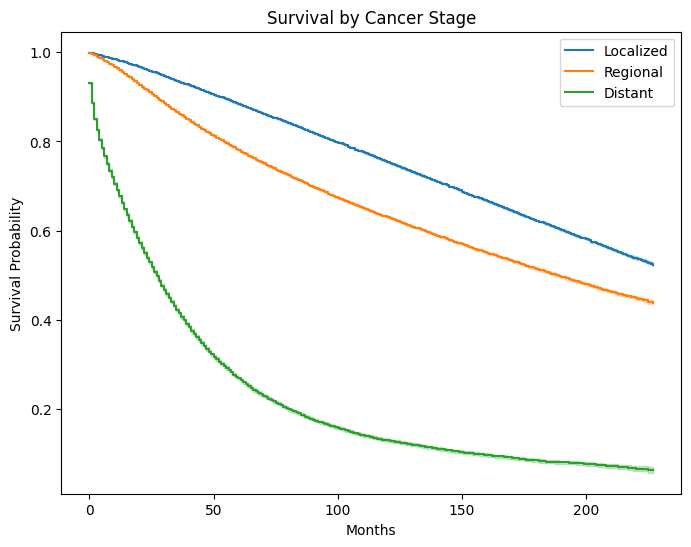

In [74]:
plt.figure(figsize=(8,6))

for stage in analysis_df['stage_clean'].unique():
    
    stage_data = analysis_df[analysis_df['stage_clean'] == stage]
    
    kmf.fit(
        stage_data['time'],
        event_observed=stage_data['event'],
        label=stage
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Cancer Stage")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

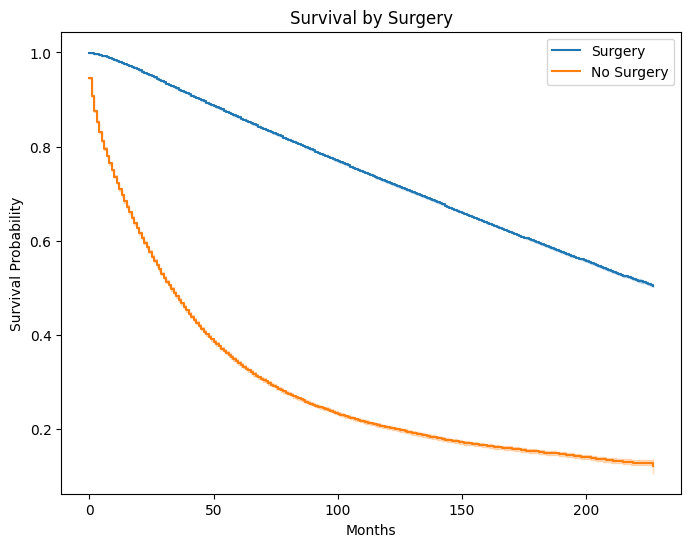

In [75]:
plt.figure(figsize=(8,6))

for s in analysis_df['surgery'].unique():
    
    subset = analysis_df[analysis_df['surgery'] == s]
    
    label = "Surgery" if s == 1 else "No Surgery"
    
    kmf.fit(
        subset['time'],
        event_observed=subset['event'],
        label=label
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Surgery")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

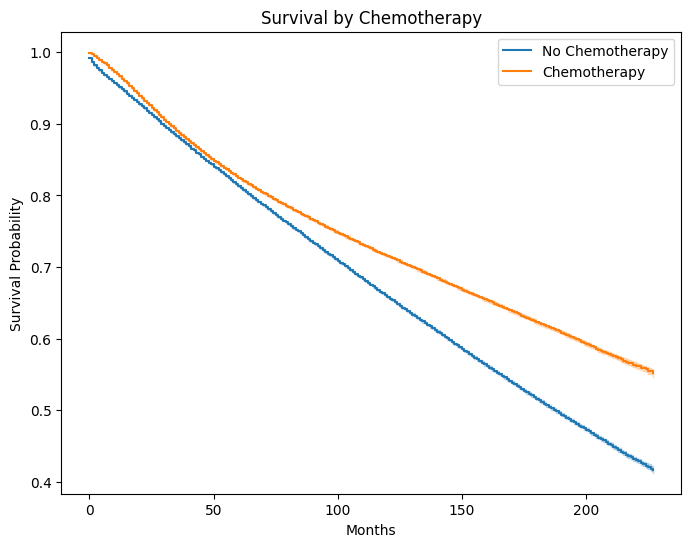

In [76]:
plt.figure(figsize=(8,6))

for c in analysis_df['chemo'].unique():
    
    subset = analysis_df[analysis_df['chemo'] == c]
    
    label = "Chemotherapy" if c == 1 else "No Chemotherapy"
    
    kmf.fit(
        subset['time'],
        event_observed=subset['event'],
        label=label
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Chemotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

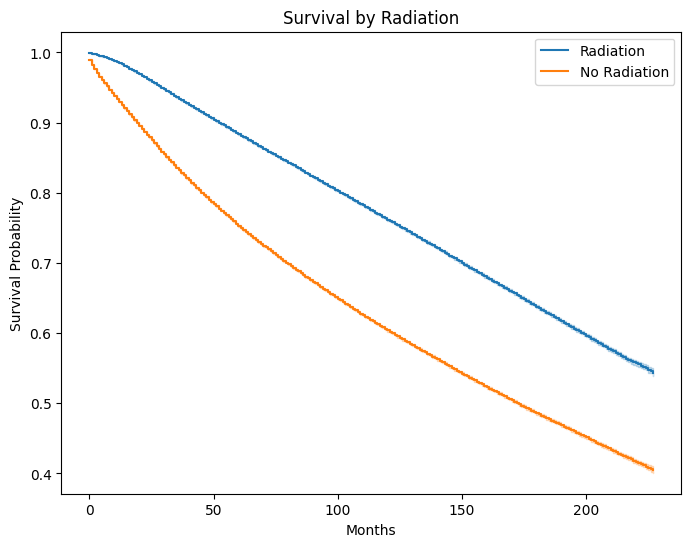

In [77]:
plt.figure(figsize=(8,6))

for r in analysis_df['radiation'].unique():
    
    subset = analysis_df[analysis_df['radiation'] == r]
    
    label = "Radiation" if r == 1 else "No Radiation"
    
    kmf.fit(
        subset['time'],
        event_observed=subset['event'],
        label=label
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Radiation")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [78]:
analysis_df.groupby('stage_clean')['chemo'].mean()

stage_clean
Distant      0.565619
Localized    0.253500
Regional     0.654196
Name: chemo, dtype: float64

In [79]:
from lifelines import CoxPHFitter

cox_df = analysis_df.dropna(subset=['grade_clean']).copy()

cph = CoxPHFitter()

cph.fit(
    cox_df[['time','event','age','stage_clean','grade_clean','chemo','radiation','surgery']],
    duration_col='time',
    event_col='event'
)

cph.print_summary()

ValueError: could not convert string to float: 'Distant'

In [80]:
cox_df = analysis_df.dropna(subset=['grade_clean']).copy()

cox_df = pd.get_dummies(
    cox_df,
    columns=['stage_clean'],
    drop_first=True
)

In [81]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cph.fit(
    cox_df[['time','event','age','grade_clean','chemo','radiation','surgery',
            'stage_clean_Regional','stage_clean_Distant']],
    duration_col='time',
    event_col='event'
)

cph.print_summary()

KeyError: "['stage_clean_Distant'] not in index"

In [82]:
cox_df.columns

Index(['age', 'grade_clean', 'chemo', 'radiation', 'surgery', 'time', 'event',
       'stage_clean_Localized', 'stage_clean_Regional'],
      dtype='object')

In [83]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cph.fit(
    cox_df[['time','event','age','grade_clean','chemo','radiation','surgery',
            'stage_clean_Localized','stage_clean_Regional']],
    duration_col='time',
    event_col='event'
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 313970 total observations, 290463 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 313970
number of events observed = 23507
   partial log-likelihood = -264341.49
         time fit was run = 2026-03-14 05:00:37 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
age                    0.04      1.04      0.00            0.04            0.04                1.04                1.04
grade_clean            0.54      1.72      0.01            0.52            0.56                1.69                1.76
chemo                 -0.23      0.79      0.02           -0.26           -0.20                0.77                0.82
radiation             -0.61      0.54      0.02           -0.64           -0.58                0.53                0.56
surgery               -1.41      0.24      0.02           -1.44           -1.37                0.24                0.25
stage_clean_Localized -1.43      0.24      0.02           -1.47           -1.39                0.23                0.25
stage_clean_Regional  -0.67      0.51      0.02           -0.71           -0.63                0.49                0.53

                       cmp to      z      p  -log2(p)
covariate                                            
age                      0.00  73.56 <0.005       inf
grade_clean              0.00  51.36 <0.005       inf
chemo                    0.00 -14.22 <0.005    150.08
radiation                0.00 -38.66 <0.005       inf
surgery                  0.00 -77.93 <0.005       inf
stage_clean_Localized    0.00 -63.69 <0.005       inf
stage_clean_Regional     0.00 -32.39 <0.005    762.12
---
Concordance = 0.84
Partial AIC = 528696.99
log-likelihood ratio test = 38679.26 on 7 df
-log2(p) of ll-ratio test = inf

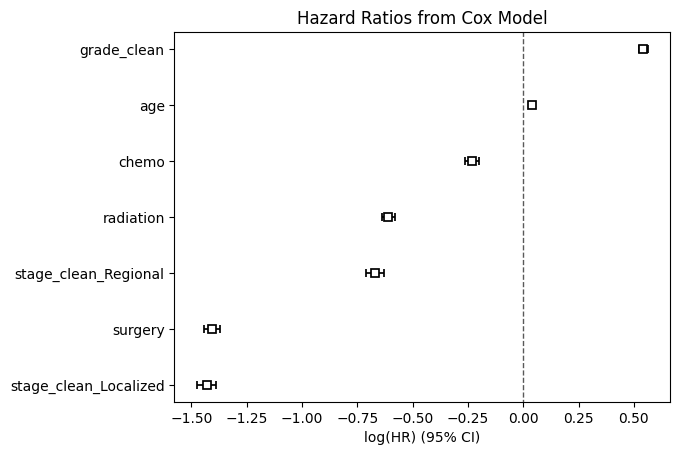

In [84]:
cph.plot()
plt.title("Hazard Ratios from Cox Model")
plt.show()

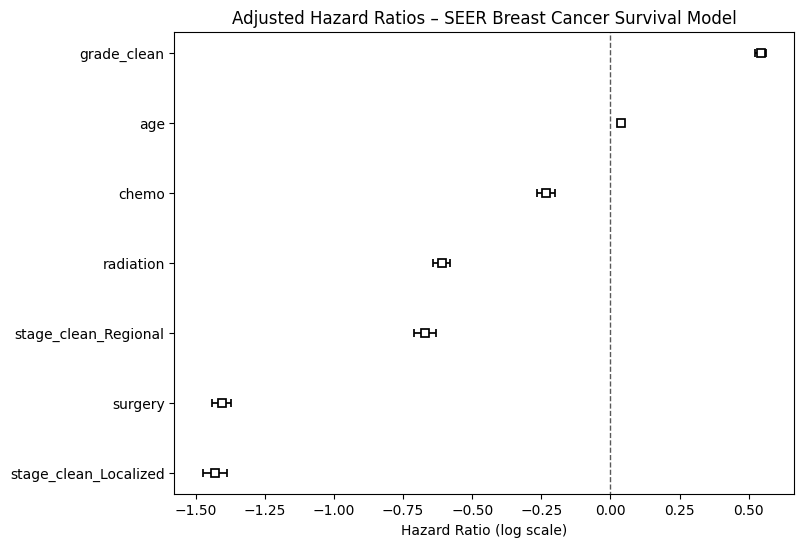

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

cph.plot()

plt.title("Adjusted Hazard Ratios – SEER Breast Cancer Survival Model")
plt.xlabel("Hazard Ratio (log scale)")
plt.show()

In [ ]:
cph.check_assumptions(cox_df, p_value_threshold=0.05)

In [ ]:
cph.check_assumptions(cox_df, show_plots=True)

In [ ]:
cph.check_assumptions(cox_df, show_plots=False)

In [88]:
cox_df.dtypes

age                        int64
grade_clean              float64
chemo                      int64
radiation                  int64
surgery                    int64
time                     float64
event                      int64
stage_clean_Localized       bool
stage_clean_Regional        bool
dtype: object

In [89]:
print(cox_df.shape)

(313970, 9)


In [90]:
cox_df.head()

,age,grade_clean,chemo,radiation,surgery,time,event,stage_clean_Localized,stage_clean_Regional
2,70,3.0,1,1,1,59.0,0,True,False
23,65,1.0,0,1,1,19.0,0,True,False
26,65,3.0,0,0,1,54.0,0,True,False
36,65,3.0,0,0,1,56.0,0,True,False
37,90,3.0,0,0,1,49.0,0,True,False


In [91]:
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest

y = Surv.from_dataframe("event", "time", cox_df)
X = cox_df.drop(columns=["time","event"])

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X, y)

,n_estimators,100
,max_depth,None
,min_samples_split,10
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [92]:
rsf.fit(X, y)

,n_estimators,100
,max_depth,None
,min_samples_split,10
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [93]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rsf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot.bar()

plt.title("Random Survival Forest Feature Importance")
plt.ylabel("Importance")

plt.show()

NotImplementedError: 

In [94]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rsf,
    X,
    y,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importance

MemoryError: Unable to allocate 287. MiB for an array with shape (313970, 60, 2) and data type float64

In [95]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X, y)

,n_estimators,300
,max_depth,None
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [96]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X, y)

,n_estimators,300
,max_depth,None
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [97]:
import numpy as np
from sklearn.inspection import permutation_importance

sample_idx = np.random.choice(len(X), size=50000, replace=False)

X_sample = X.iloc[sample_idx]
y_sample = y[sample_idx]

result = permutation_importance(
    rsf,
    X_sample,
    y_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importance

stage_clean_Localized    0.082539
age                      0.074780
surgery                  0.049717
stage_clean_Regional     0.026838
grade_clean              0.024071
radiation                0.017988
chemo                    0.006575
dtype: float64

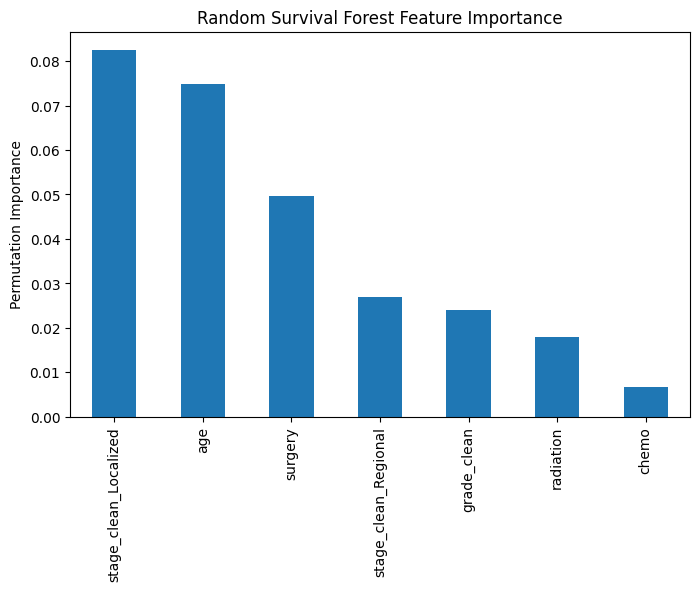

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
importance.plot.bar()

plt.title("Random Survival Forest Feature Importance")
plt.ylabel("Permutation Importance")

plt.savefig(f"{FIG_PATH}/rsf_feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [99]:
risk_scores = rsf.predict(X)

cox_df["risk_score"] = risk_scores

In [100]:
cox_df["risk_group"] = pd.qcut(
    cox_df["risk_score"],
    q=3,
    labels=["Low Risk","Medium Risk","High Risk"]
)

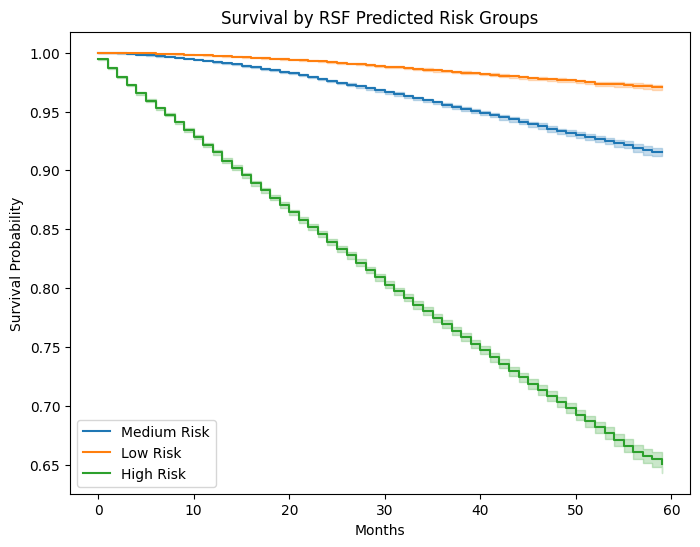

In [101]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in cox_df["risk_group"].unique():

    mask = cox_df["risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask,"time"],
        event_observed=cox_df.loc[mask,"event"],
        label=group
    )

    kmf.plot_survival_function()

plt.title("Survival by RSF Predicted Risk Groups")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [102]:
import xgboost as xgb
xgb.__version__

ModuleNotFoundError: No module named 'xgboost'

In [103]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.7 MB/s eta 0:00:16
    --------------------------------------- 1.6/101.7 MB 4.7 MB/s eta 0:00:22
    --------------------------------------- 2.4/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.1/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.9/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 4.7/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 5.2/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.3/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 7.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.7/101.7 MB 4.0 MB/s eta 0

In [104]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [105]:
import numpy as np
import xgboost as xgb

X_xgb = X.copy()

y_time = cox_df["time"].values
y_event = cox_df["event"].values

# XGBoost Cox expects negative time for censored observations
y_xgb = np.where(y_event == 1, y_time, -y_time)

dtrain = xgb.DMatrix(X_xgb, label=y_xgb)

In [106]:
params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "tree_method": "gpu_hist",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

In [107]:
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=300
)

XGBoostError: Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}

In [108]:
params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "tree_method": "hist",   # CPU optimized
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

In [109]:
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=300
)

In [110]:
xgb_risk = xgb_model.predict(dtrain)

cox_df["xgb_risk_score"] = xgb_risk

In [111]:
cox_df["xgb_risk_group"] = pd.qcut(
    cox_df["xgb_risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

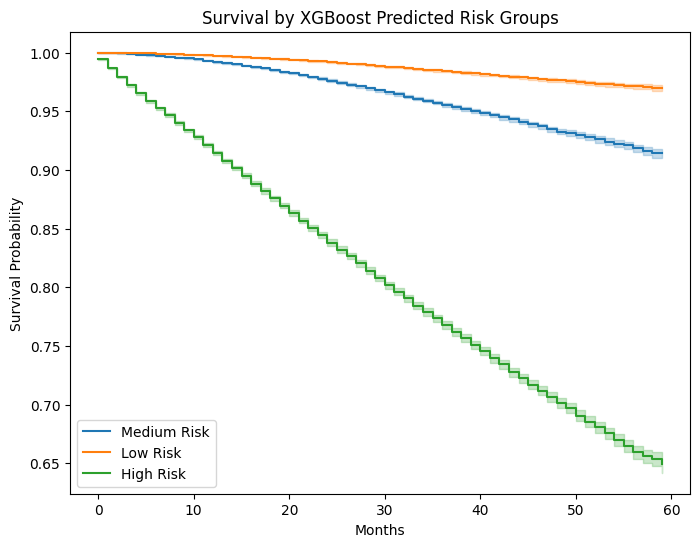

In [112]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in cox_df["xgb_risk_group"].unique():

    mask = cox_df["xgb_risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask, "time"],
        event_observed=cox_df.loc[mask, "event"],
        label=group
    )

    kmf.plot_survival_function()

plt.title("Survival by XGBoost Predicted Risk Groups")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [113]:
cox_df["cox_risk_score"] = cph.predict_partial_hazard(cox_df)

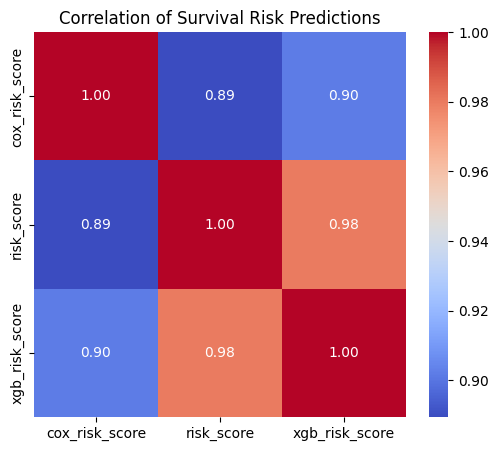

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

risk_compare = cox_df[
    ["cox_risk_score", "risk_score", "xgb_risk_score"]
]

plt.figure(figsize=(6,5))

sns.heatmap(
    risk_compare.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Survival Risk Predictions")

plt.savefig(f"{FIG_PATH}/risk_score_correlation.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

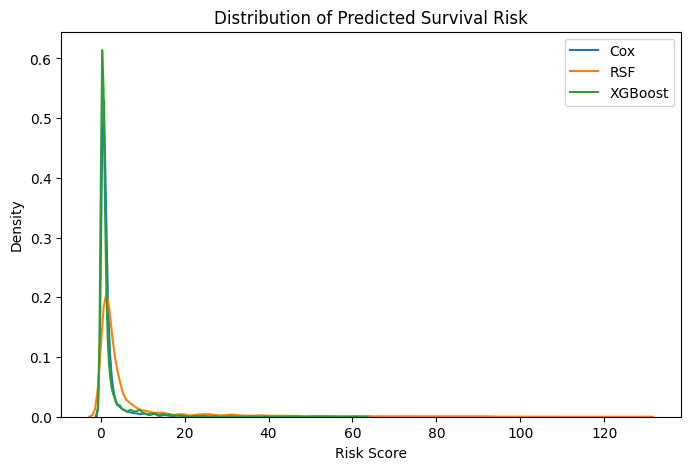

In [115]:
plt.figure(figsize=(8,5))

sns.kdeplot(cox_df["cox_risk_score"], label="Cox")
sns.kdeplot(cox_df["risk_score"], label="RSF")
sns.kdeplot(cox_df["xgb_risk_score"], label="XGBoost")

plt.title("Distribution of Predicted Survival Risk")
plt.xlabel("Risk Score")
plt.legend()

plt.show()

In [116]:
cox_df["cox_risk_group"] = pd.qcut(
    cox_df["cox_risk_score"],
    q=3,
    labels=["Low Risk","Medium Risk","High Risk"]
)

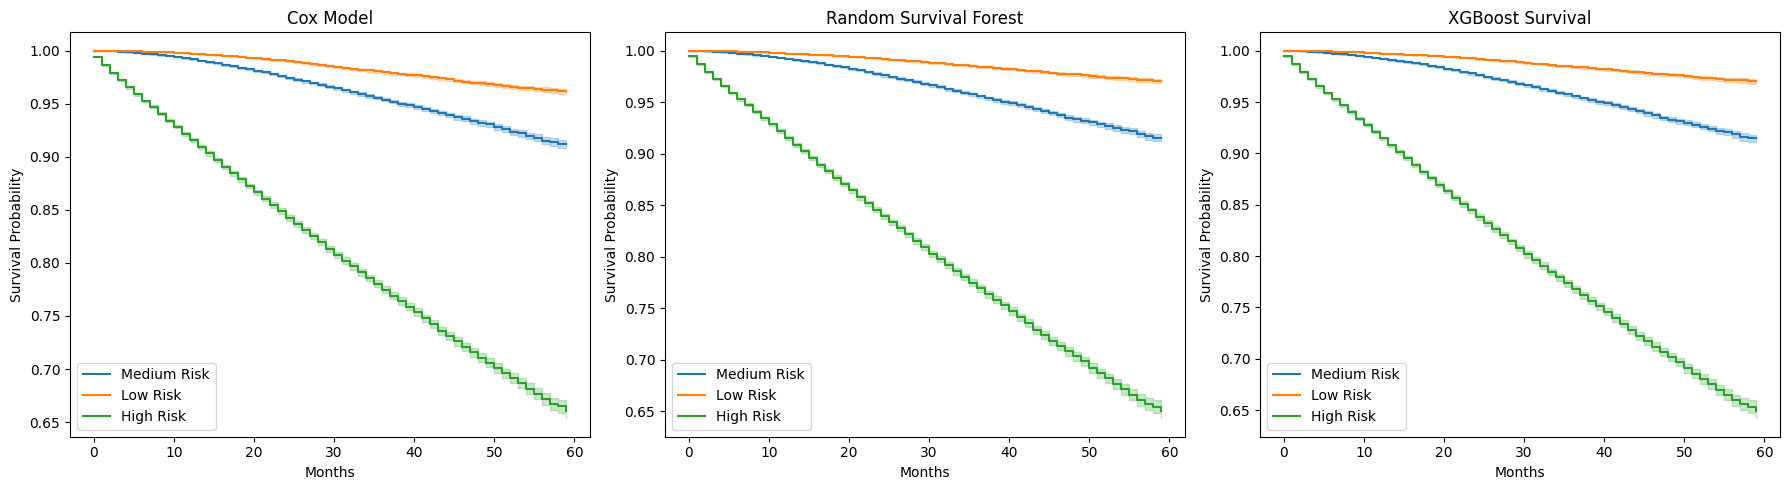

In [138]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1,3, figsize=(18,5))

models = {
    "Cox Model": "cox_risk_group",
    "Random Survival Forest": "risk_group",
    "XGBoost Survival": "xgb_risk_group"
}

for ax,(title,group_col) in zip(axes,models.items()):

    for group in cox_df[group_col].unique():

        mask = cox_df[group_col] == group

        kmf.fit(
            durations=cox_df.loc[mask,"time"],
            event_observed=cox_df.loc[mask,"event"],
            label=group
        )

        kmf.plot_survival_function(ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival Probability")

plt.tight_layout()

plt.savefig(f"{FIG_PATH}/model_risk_stratification.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [118]:
plt.savefig("figure_name.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [119]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [120]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

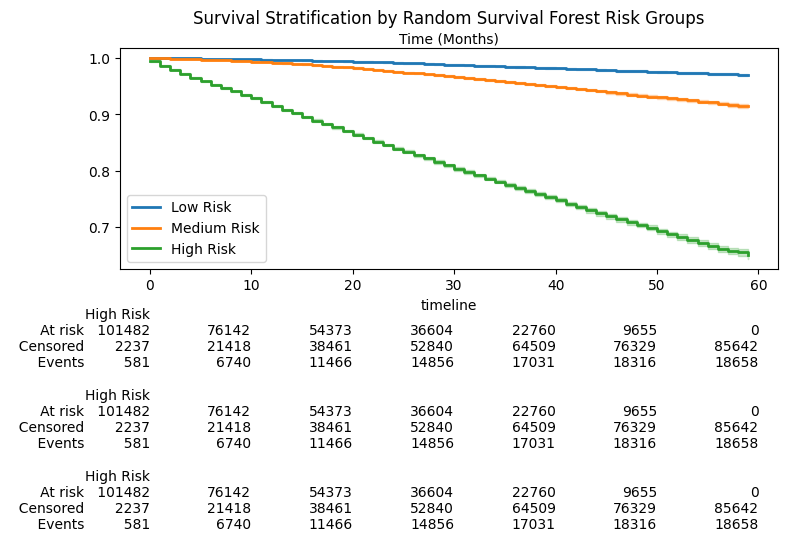

In [140]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

ax = plt.subplot(111)

models = ["Low Risk","Medium Risk","High Risk"]

for group in models:

    mask = cox_df["risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask,"time"],
        event_observed=cox_df.loc[mask,"event"],
        label=group
    )

    kmf.plot_survival_function(
        ax=ax,
        ci_show=True,
        linewidth=2
    )

add_at_risk_counts(
    *[kmf.fit(
        cox_df.loc[cox_df["risk_group"] == g,"time"],
        cox_df.loc[cox_df["risk_group"] == g,"event"]
      ) for g in models],
    ax=ax
)

plt.title("Survival Stratification by Random Survival Forest Risk Groups")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")

plt.tight_layout()

plt.savefig(f"{FIG_PATH}/rsf_survival_stratification.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

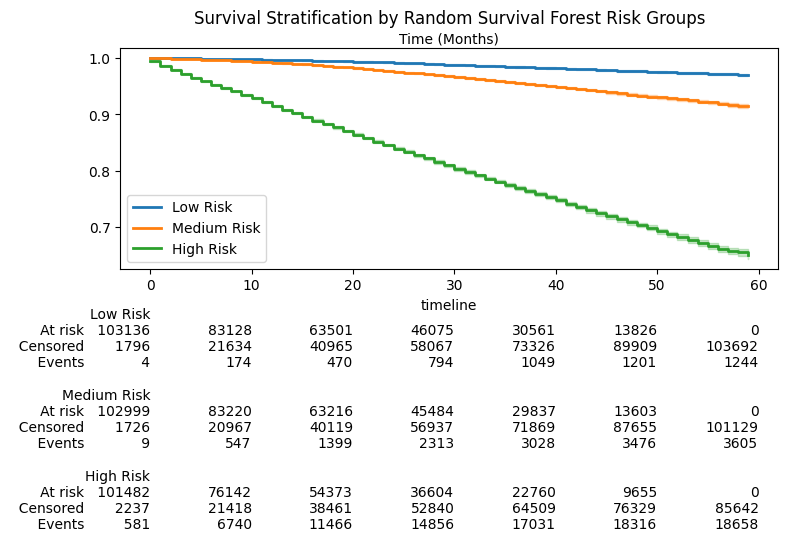

In [122]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

km_low = KaplanMeierFitter()
km_med = KaplanMeierFitter()
km_high = KaplanMeierFitter()

mask_low = cox_df["risk_group"] == "Low Risk"
mask_med = cox_df["risk_group"] == "Medium Risk"
mask_high = cox_df["risk_group"] == "High Risk"

km_low.fit(
    cox_df.loc[mask_low, "time"],
    cox_df.loc[mask_low, "event"],
    label="Low Risk"
)

km_med.fit(
    cox_df.loc[mask_med, "time"],
    cox_df.loc[mask_med, "event"],
    label="Medium Risk"
)

km_high.fit(
    cox_df.loc[mask_high, "time"],
    cox_df.loc[mask_high, "event"],
    label="High Risk"
)

plt.figure(figsize=(8,6))
ax = plt.subplot(111)

km_low.plot_survival_function(ax=ax, ci_show=True, linewidth=2)
km_med.plot_survival_function(ax=ax, ci_show=True, linewidth=2)
km_high.plot_survival_function(ax=ax, ci_show=True, linewidth=2)

add_at_risk_counts(km_low, km_med, km_high, ax=ax)

plt.title("Survival Stratification by Random Survival Forest Risk Groups")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")

plt.tight_layout()
plt.show()

In [123]:
from lifelines.utils import concordance_index

In [124]:
cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

cox_cindex

np.float64(0.8395945570355179)

In [125]:
cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

cox_cindex

np.float64(0.8395945570355179)

In [126]:
rsf_cindex = concordance_index(
    cox_df["time"],
    -cox_df["risk_score"],
    cox_df["event"]
)

rsf_cindex

np.float64(0.8510265812473735)

In [127]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Cox PH", "Random Survival Forest", "XGBoost Survival"],
    "C-index": [cox_cindex, rsf_cindex, xgb_cindex]
})

results

NameError: name 'xgb_cindex' is not defined

In [128]:
from lifelines.utils import concordance_index

cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

print("Cox C-index:", cox_cindex)

Cox C-index: 0.8395945570355179


In [129]:
from lifelines.utils import concordance_index

cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

print("Cox C-index:", cox_cindex)

Cox C-index: 0.8395945570355179


In [130]:
xgb_cindex = concordance_index(
    cox_df["time"],
    -cox_df["xgb_risk_score"],
    cox_df["event"]
)

print("XGBoost C-index:", xgb_cindex)

XGBoost C-index: 0.8509845509385888


In [131]:
xgb_cindex = concordance_index(
    cox_df["time"],
    -cox_df["xgb_risk_score"],
    cox_df["event"]
)

print("XGBoost C-index:", xgb_cindex)

XGBoost C-index: 0.8509845509385888


In [132]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Cox PH", "Random Survival Forest", "XGBoost Survival"],
    "C-index": [cox_cindex, rsf_cindex, xgb_cindex]
})

results

,Model,C-index
0,Cox PH,0.839595
1,Random Survival Forest,0.851027
2,XGBoost Survival,0.850985


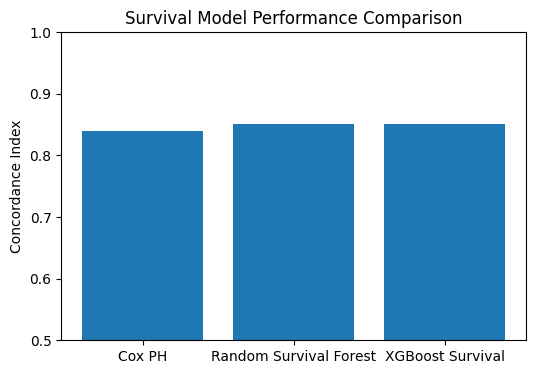

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["C-index"])

plt.ylabel("Concordance Index")
plt.title("Survival Model Performance Comparison")

plt.ylim(0.5,1)

plt.savefig(f"{FIG_PATH}/model_performance_cindex.png",
            dpi=300,
            bbox_inches="tight")

plt.show()